# Phase 1 - Week 3 - Day 3 PM - Time Series - Part 2

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

## Data Loading

In [2]:
df_raw = pd.read_csv('https://raw.githubusercontent.com/FTDS-learning-materials/phase-1/refs/heads/v2.3/w3/P1W3D3AM%20-%20Time%20Series%20-%20Part%202%20-%20bbca_historical.csv')
df_raw.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2020-08-17 00:00:00-04:00,44.068247,44.209831,43.962059,44.209831,62100,0.0,0.0,0.0
1,2020-08-18 00:00:00-04:00,44.351406,44.369105,44.015145,44.227520,77100,0.0,0.0,0.0
2,2020-08-19 00:00:00-04:00,44.298322,44.351414,43.908962,43.944359,105400,0.0,0.0,0.0
3,2020-08-20 00:00:00-04:00,43.731974,44.156731,43.661183,44.156731,87500,0.0,0.0,0.0
4,2020-08-21 00:00:00-04:00,43.820473,43.944359,43.661190,43.908962,147600,0.0,0.0,0.0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1255 non-null   object 
 1   Open           1255 non-null   float64
 2   High           1255 non-null   float64
 3   Low            1255 non-null   float64
 4   Close          1255 non-null   float64
 5   Volume         1255 non-null   int64  
 6   Dividends      1255 non-null   float64
 7   Stock Splits   1255 non-null   float64
 8   Capital Gains  1255 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 88.4+ KB


In [4]:
df_raw.index

RangeIndex(start=0, stop=1255, step=1)

## Data Preprocessing

In [5]:
df_raw.set_index('Date', inplace=True)
df_raw.index

Index(['2020-08-17 00:00:00-04:00', '2020-08-18 00:00:00-04:00',
       '2020-08-19 00:00:00-04:00', '2020-08-20 00:00:00-04:00',
       '2020-08-21 00:00:00-04:00', '2020-08-24 00:00:00-04:00',
       '2020-08-25 00:00:00-04:00', '2020-08-26 00:00:00-04:00',
       '2020-08-27 00:00:00-04:00', '2020-08-28 00:00:00-04:00',
       ...
       '2025-08-01 00:00:00-04:00', '2025-08-04 00:00:00-04:00',
       '2025-08-05 00:00:00-04:00', '2025-08-06 00:00:00-04:00',
       '2025-08-07 00:00:00-04:00', '2025-08-08 00:00:00-04:00',
       '2025-08-11 00:00:00-04:00', '2025-08-12 00:00:00-04:00',
       '2025-08-13 00:00:00-04:00', '2025-08-14 00:00:00-04:00'],
      dtype='object', name='Date', length=1255)

In [6]:
df = pd.DataFrame(df_raw['Close'])
df

,Close
Date,
2020-08-17 00:00:00-04:00,44.209831
2020-08-18 00:00:00-04:00,44.227520
2020-08-19 00:00:00-04:00,43.944359
2020-08-20 00:00:00-04:00,44.156731
2020-08-21 00:00:00-04:00,43.908962
...,...
2025-08-08 00:00:00-04:00,82.449997
2025-08-11 00:00:00-04:00,82.419998
2025-08-12 00:00:00-04:00,82.690002


In [7]:
df.index = pd.to_datetime(df.index, utc=True)

In [8]:
df.index.dtype

datetime64[ns, UTC]

In [9]:
df.index = df.index.tz_convert('Asia/Jakarta')

In [10]:
df.head()

,Close
Date,
2020-08-17 11:00:00+07:00,44.209831
2020-08-18 11:00:00+07:00,44.227520
2020-08-19 11:00:00+07:00,43.944359
2020-08-20 11:00:00+07:00,44.156731
2020-08-21 11:00:00+07:00,43.908962


In [11]:
df.index = df.index.date
df.head()

,Close
2020-08-17,44.209831
2020-08-18,44.227520
2020-08-19,43.944359
2020-08-20,44.156731
2020-08-21,43.908962


## EDA

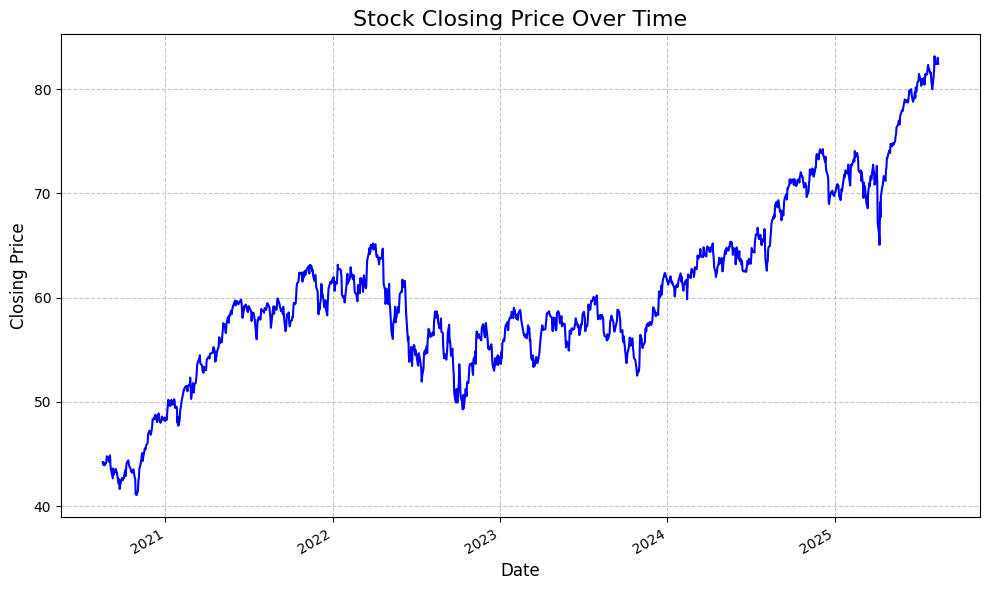

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index, df['Close'], linestyle='-', color='b')
ax.set_title('Stock Closing Price Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Closing Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Time Series Decomposition

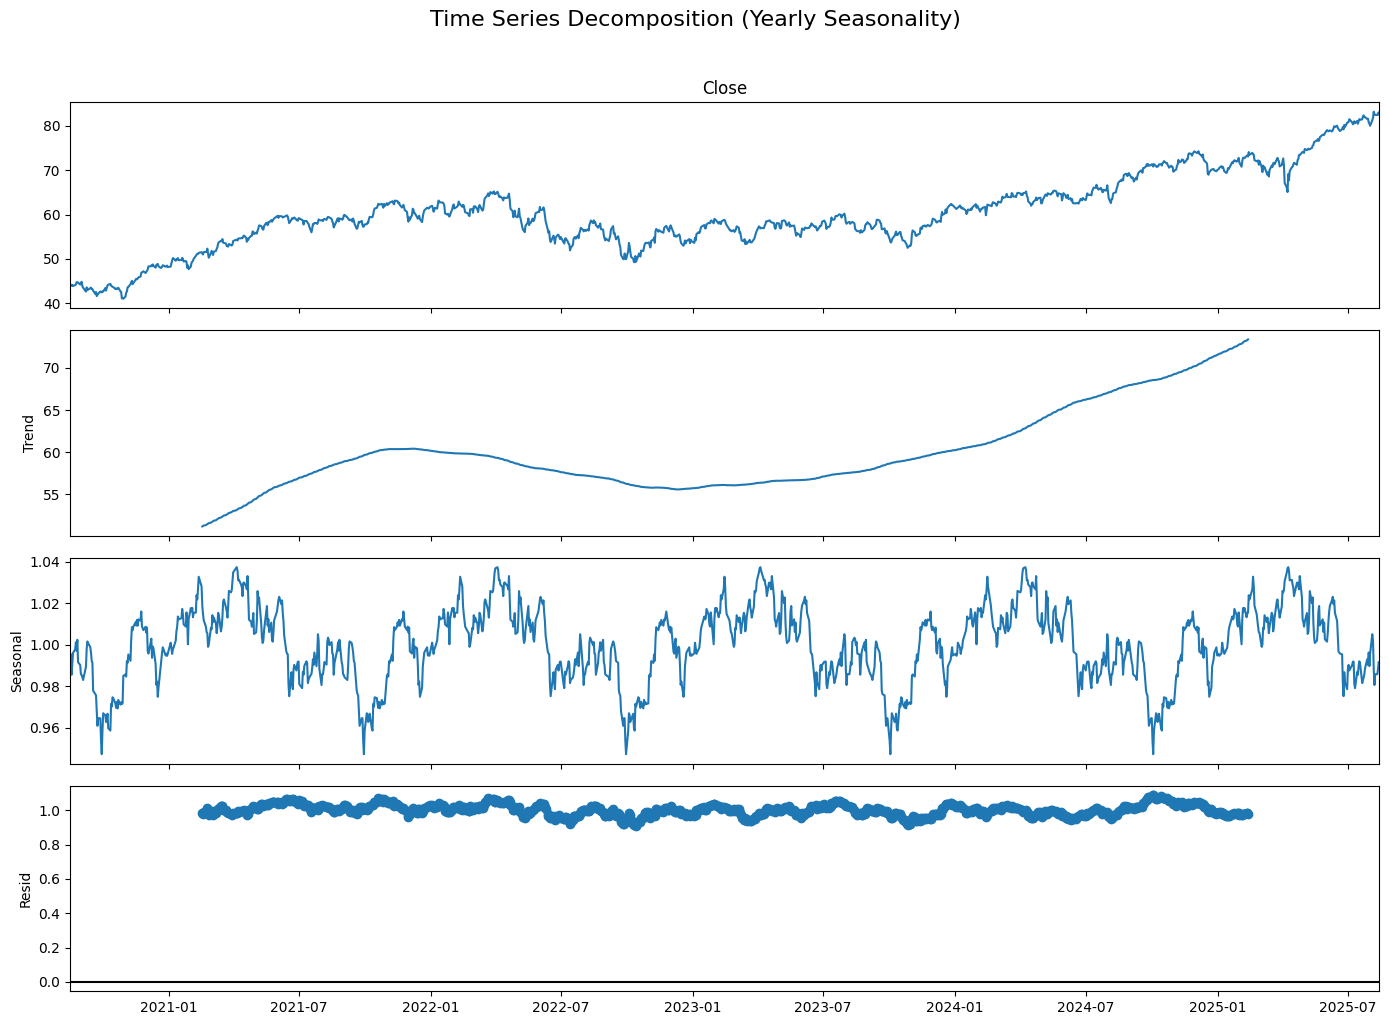

In [13]:
decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=252)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition (Yearly Seasonality)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Data Splitting

In [14]:
len_train = round(len(df) * 0.9)

df_close_train = df[:len_train]
df_close_test = df[len_train:]

print(f"total train: {len_train}")
print(f"total test: {len(df)-len_train}")

total train: 1130
total test: 125


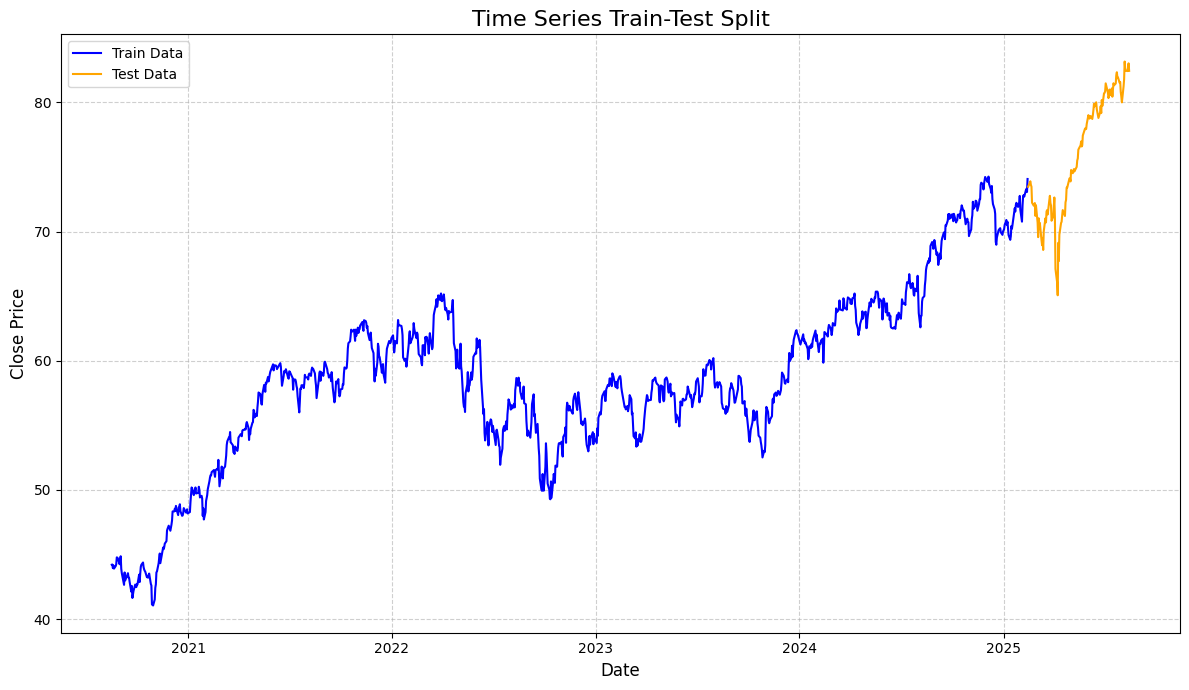

In [15]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(df_close_train.index, df_close_train['Close'], color='blue', label='Train Data')
ax.plot(df_close_test.index, df_close_test['Close'], color='orange', label='Test Data')
ax.set_title('Time Series Train-Test Split', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

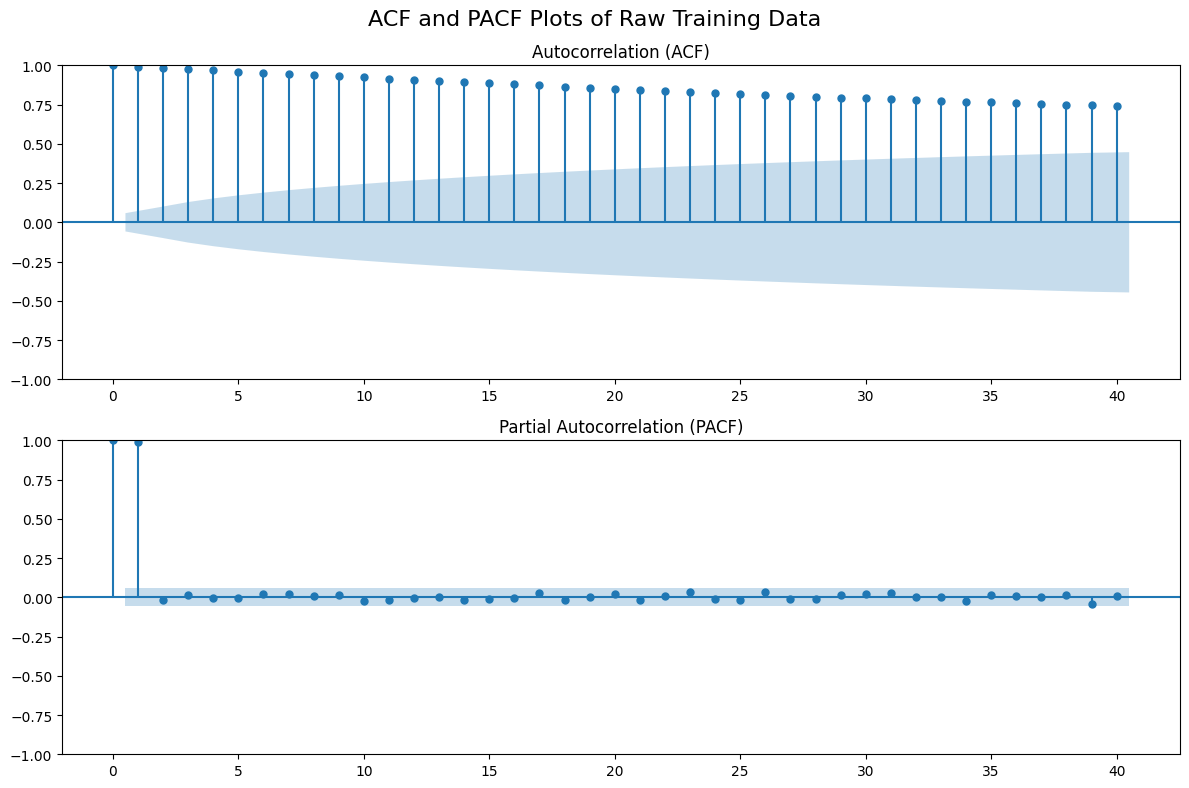

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('ACF and PACF Plots of Raw Training Data', fontsize=16)
plot_acf(df_close_train['Close'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation (ACF)')
plot_pacf(df_close_train['Close'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

In [17]:
def perform_adf_test(series: pd.Series, series_name: str = "the series"):
    """
    Performs and prints the results of the Augmented Dickey-Fuller test.

    Args:
        series (pd.Series): The time series data to test.
        series_name (str): A descriptive name for the data being tested.
    """
    print(f"--- ADF Test Results for: {series_name} ---")

    # Perform the ADF test
    result = adfuller(series.dropna()) # dropna() is important for differenced series

    # Print the main results
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    # Print the conclusion
    print('\n--- Conclusion ---')
    if result[1] <= 0.05:
        print("The data is likely stationary.")
    else:
        print("The data is likely non-stationary.")
    print("-" * 40)

In [18]:
perform_adf_test(df_close_train['Close'], series_name="Raw Training Data")

--- ADF Test Results for: Raw Training Data ---
ADF Statistic: -1.4055693008793273
p-value: 0.5796032324194125
Critical Values:
	1%: -3.4361656672131806
	5%: -2.864107957764881
	10%: -2.568137251515397

--- Conclusion ---
The data is likely non-stationary.
----------------------------------------


In [19]:
df_close_train.diff()

,Close
2020-08-17,NaN
2020-08-18,0.017689
2020-08-19,-0.283161
2020-08-20,0.212372
2020-08-21,-0.247768
...,...
2025-02-07,-0.118996
2025-02-10,0.495834
2025-02-11,0.109077
2025-02-12,-0.237991


In [20]:
df_diff = df_close_train.diff().dropna()
df_diff.head()

,Close
2020-08-18,0.017689
2020-08-19,-0.283161
2020-08-20,0.212372
2020-08-21,-0.247768
2020-08-24,0.194672


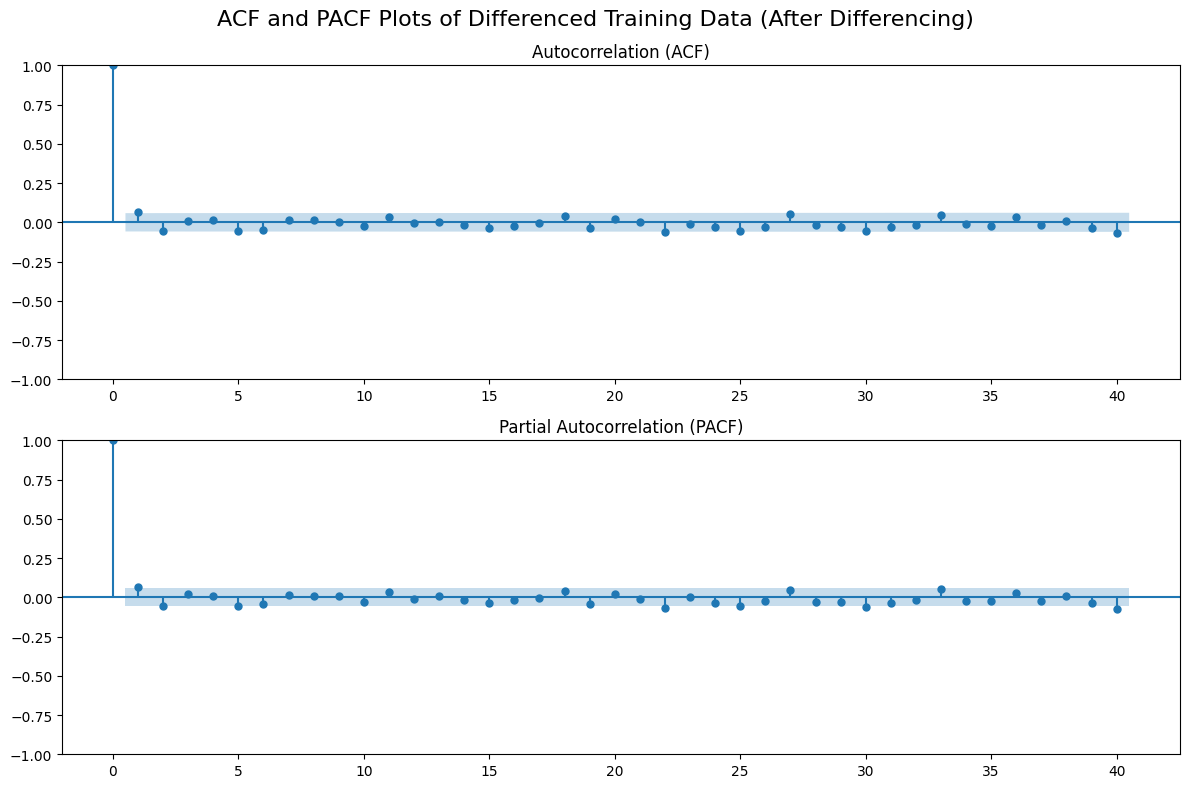

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('ACF and PACF Plots of Differenced Training Data (After Differencing)', fontsize=16)
plot_acf(df_diff['Close'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation (ACF)')
plot_pacf(df_diff['Close'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

In [22]:
perform_adf_test(df_diff['Close'], series_name="Differenced Training Data")

--- ADF Test Results for: Differenced Training Data ---
ADF Statistic: -24.288069673262456
p-value: 0.0
Critical Values:
	1%: -3.4361656672131806
	5%: -2.864107957764881
	10%: -2.568137251515397

--- Conclusion ---
The data is likely stationary.
----------------------------------------


In [23]:
def find_best_arima(data: pd.Series, p_range, d_order, q_range):
    """
    Performs a grid search to find the best ARIMA(p,d,q) order.

    Args:
        data (pd.Series): The time series data.
        p_range (range): A range of values for the AR order 'p'.
        d_order (int): The fixed differencing order 'd'.
        q_range (range): A range of values for the MA order 'q'.
    """
    best_aic = float('inf')
    best_order = None
    results = []

    for p in p_range:
        for q in q_range:
            order = (p, d_order, q)
            try:
                model = ARIMA(data, order=order)
                result = model.fit()

                results.append({'Order': order, 'AIC': result.aic})

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order

            except Exception as e:
                continue
    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    return results_df


In [24]:
p_values = range(0, 2)
d_value = 1
q_values = range(0, 2)

best_models_df = find_best_arima(df_close_train, p_values, d_value, q_values)

print("Top 5 ARIMA Models by AIC:")
print(best_models_df.head())

Top 5 ARIMA Models by AIC:
       Order          AIC
0  (1, 1, 1)  2052.273929
1  (0, 1, 1)  2052.617239
2  (1, 1, 0)  2053.229569
3  (0, 1, 0)  2056.158748


## ARIMA

In [25]:
# Model definition
model = ARIMA(df_close_train, order = (1,1,0))

# Model training
result = model.fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1130
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -1024.615
Date:                Tue, 02 Sep 2025   AIC                           2053.230
Time:                        04:52:11   BIC                           2063.288
Sample:                             0   HQIC                          2057.030
                               - 1130                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0661      0.027      2.494      0.013       0.014       0.118
sigma2         0.3596      0.013     28.339      0.000       0.335       0.384
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                40.04
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.20   Skew:                            -0.14
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
train_predictions = result.predict(start=df_close_train.index[0], end=df_close_train.index[-1])

In [27]:
pred_train = pd.DataFrame(train_predictions, index=df_close_train.index)
pred_train

,predicted_mean
2020-08-17,0.000000
2020-08-18,44.209832
2020-08-19,44.228689
2020-08-20,43.925645
2020-08-21,44.170766
...,...
2025-02-07,72.823862
2025-02-10,72.691759
2025-02-11,73.228227
2025-02-12,73.311744


In [28]:
train_concat = pd.concat([df_close_train, pred_train], axis=1)
train_concat

,Close,predicted_mean
2020-08-17,44.209831,0.000000
2020-08-18,44.227520,44.209832
2020-08-19,43.944359,44.228689
2020-08-20,44.156731,43.925645
2020-08-21,43.908962,44.170766
...,...,...
2025-02-07,72.699623,72.823862
2025-02-10,73.195457,72.691759
2025-02-11,73.304535,73.228227
2025-02-12,73.066544,73.311744


In [29]:
test_predictions = result.forecast(steps=len(df_close_test))

In [30]:
pred_test = pd.DataFrame(test_predictions)
pred_test.head()

,predicted_mean
1130,74.134325
1131,74.138700
1132,74.138989
1133,74.139008
1134,74.139010


In [31]:
pred_test.index = df_close_test.index
pred_test.head()

,predicted_mean
2025-02-14,74.134325
2025-02-18,74.138700
2025-02-19,74.138989
2025-02-20,74.139008
2025-02-21,74.139010


In [32]:
test_concat = pd.concat([df_close_test, pred_test], axis=1)
test_concat

,Close,predicted_mean
2025-02-14,73.463211,74.134325
2025-02-18,73.889626,74.138700
2025-02-19,73.602043,74.138989
2025-02-20,73.473122,74.139008
2025-02-21,72.233528,74.139010
...,...,...
2025-08-08,82.449997,74.139010
2025-08-11,82.419998,74.139010
2025-08-12,82.690002,74.139010
2025-08-13,83.019997,74.139010


In [33]:
mae_train = mean_absolute_error(df_close_train, train_predictions)
mae_test = mean_absolute_error(df_close_test, test_predictions)
print(f"Train MAE: {mae_train:.4f}")
print(f"Test MAE:  {mae_test:.4f}")

Train MAE: 0.5013
Test MAE:  4.2690


## SARIMA

In [34]:
model2 = sm.tsa.statespace.SARIMAX(df_close_train['Close'],
                                  order=(1, 1, 0),
                                  seasonal_order=(0, 0, 0, 0))
result2 = model2.fit(disp=False)
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1130
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1024.615
Date:                Tue, 02 Sep 2025   AIC                           2053.230
Time:                        04:52:23   BIC                           2063.288
Sample:                             0   HQIC                          2057.030
                               - 1130                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0661      0.027      2.494      0.013       0.014       0.118
sigma2         0.3596      0.013     28.339      0.000       0.335       0.384
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                40.04
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.20   Skew:                            -0.14
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Predict on the training data (in-sample prediction)
# The start and end dates should match your df_close_train
# your code here
train_predictions_sarima = ...

# Forecast on the test data (out-of-sample forecasting)
# The number of steps should be equal to the length of your df_close_test
# your code here
test_predictions_sarima = ...

In [ ]:
# Create a DataFrame for the training set
# your code here
df_train_results = ...
print("--- Train Set: Actual vs. Predicted ---")
print(df_train_results.head())

# Create a DataFrame for the test set
# your code here
df_test_results = ...
print("\n--- Test Set: Actual vs. Predicted ---")
print(df_test_results.head())

In [ ]:
# Calculate MAE for the training set
# your code here
mae_train_sarima = ...

# Calculate MAE for the test set
# your code here
mae_test_sarima = ...

print(f"SARIMA Train MAE: {mae_train_sarima:.4f}")
print(f"SARIMA Test MAE:  {mae_test_sarima:.4f}")

## Determine the Best Model
Write your comparison logic for ARIMA vs. SARIMA, then identify the best model.

Explain which model was chosen and why. Discuss its performance based on the Test MAE and what that error value means in the context of the stock price.

## Inference

**Note on inference**: The forecast begins on the first business day immediately following the last date in the test set. This ensures the model is predicting truly future values that were not used in either the training or evaluation phases.

Expected output:

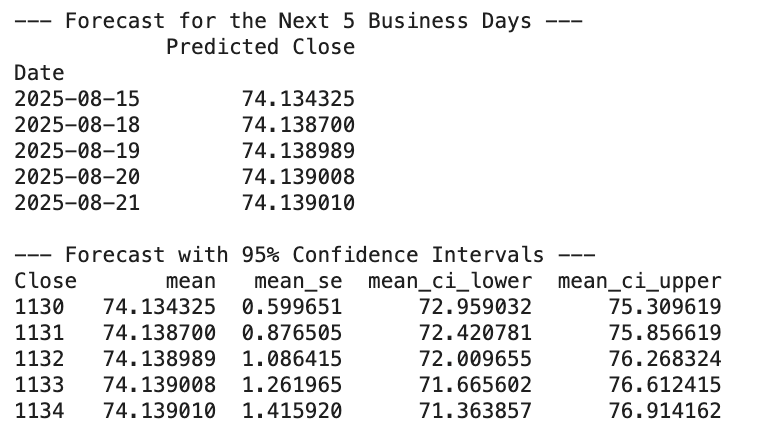

In [ ]:
# Define the number of steps to forecast ahead (e.g. 1 week = 5 business days)
n_steps = 5
forecast = result.forecast(steps=n_steps)

# Create a clear DataFrame for the forecast results with date range out of test set
forecast_df = ...

# Get Forecast with Confidence Intervals
# For a more complete picture, use get_forecast()
forecast_with_ci =
# using 95% confidence
forecast_summary =

forecast_summary